In [1]:
#needed imports
from collections import OrderedDict
import copy
import logging
import os
import urllib.request
import zipfile
import glob 

from astropy.time import Time
import astropy.units as u
from IPython.display import display, Markdown
from gaiasupdate.epoch_astrometry import GaiaEpochAstrometryArchive
from astropy.table import Table
import numpy as np

from periapsis.data.gaia import GaiaData
from periapsis.stats import stat_funcs as st 
from periapsis.plotting.plots import all_plots 
from periapsis.fitting.gaia_mcmclinear import MCMCGaia
from periapsis.fitting.gaia_ultranestlinear import UltraNestGaia
from periapsis.prior.uniform_prior import UniformPrior

Please note the archive will not be accessible on 27 July at 11:30 CEST, for some minutes, due to maintenance tasks. Apologies for the inconveniences.


Fitting Gaia BH3 with Periapsis

First, we need to grab the data. Data retrieval coutersy of https://github.com/esa/gaia-bhthree/blob/gaia-dr4-prerelease/Gaia-DR4-prerelease_BH3_fit_astrometric_orbit.ipynb

In [2]:
url = "https://anonftp.cosmos.esa.int/pub/GAIA_PUBLIC_DATA/Gaia_DR4/dr4-prerelease/gaia-dr4-prerelease-epoch-astrometry_2026-06-26.zip"

local_dir = os.getcwd()

download_path = os.path.join(local_dir, 'downloaded_file.zip')
extract_path = os.path.join(local_dir, 'extracted_files')

if not os.path.isfile(download_path):

    # Download the file
    urllib.request.urlretrieve(url, os.path.basename(download_path))
   

with zipfile.ZipFile(download_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)



epoch_astrometry_file = glob.glob(os.path.join(extract_path, '*.xml'))[0]


table = Table.read(epoch_astrometry_file, format="votable")
epoch_astrometry = table.to_pandas()


In [3]:
name_dict = {'Gaia BH3': 4318465066420528000,
    'HD 114762': 3937211745905473024,
    'Gaia-4': 1457486023639239296}


source_id = name_dict['Gaia BH3'] # for Gaia BH3
# source_id = name_dict['HD 114762'] 
# source_id = name_dict['Gaia-4'] 

m1_MS = 0.76  # Primary star mass for Gaia BH3
target_ra_deg = 294.8278502411 # Right Ascension for Gaia BH3
target_dec_deg = 14.9309190720 # Declination for Gaia BH3


epoch_astrometry_bh3 = epoch_astrometry[epoch_astrometry['source_id'] == source_id]

In [4]:
ea = GaiaEpochAstrometryArchive.from_dataframe(epoch_astrometry_bh3)

# use only data used by the Gaia DR4 core astrometric solution
ea.epoch_data = ea.epoch_data.epochastrometryarchive.filter_on_used_by_agis()

# sort by increasing time
ea.epoch_data.epochastrometryarchive.sort_by_column('obs_time_tcb')

# set auxiliary fields
ea.epoch_data.epochastrometryarchive.set_relative_time() # sets 'relative_time_year','relative_time_day'
ea.epoch_data = ea.epoch_data.epochastrometryarchive.set_scan_angle_derived_columns() # sets 'sin_theta', 'cos_theta', 'sin_theta_time', 'cos_theta_time
ea.epoch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558 entries, 0 to 557
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   solution_id                558 non-null    int64  
 1   source_id                  558 non-null    int64  
 2   transit_id                 558 non-null    int64  
 3   ra0                        558 non-null    float64
 4   dec0                       558 non-null    float64
 5   agis_source_excess_noise   558 non-null    float32
 6   obs_time_tcb               558 non-null    int64  
 7   obs_time_bary_corr         558 non-null    float32
 8   scan_pos_angle             558 non-null    float64
 9   zeta                       558 non-null    float32
 10  parallax_factor_al         558 non-null    float32
 11  parallax_factor_ac         558 non-null    float32
 12  colour_factor_al           558 non-null    float64
 13  colour_factor_ac           558 non-null    object 

/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: UserWarning: Warning: converting a masked element to nan.
  return arr.astype(dtype, copy=True)
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: UserWarning: Warning: converting a masked element to nan.
  return arr.astype(dtype, copy=True)
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: UserWarning: Warning: converting a masked element to nan.
  return arr.astype(dtype, copy=True)
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: UserWarning: Warning: converting a masked element to nan.
  return arr.astype(dtype, copy=True)


Now, we grab needed data to perform orbital fit

In [5]:
gaia_astrometry = ea.epoch_data.copy()

spsi = gaia_astrometry['sin_theta'].values
cpsi = gaia_astrometry['cos_theta'].values
ti = gaia_astrometry['relative_time_year'].values
plx_factor = gaia_astrometry['parallax_factor_al'].values
x = gaia_astrometry['centroid_pos_al'].values
err = gaia_astrometry['centroid_pos_error_al'].values

In [6]:
data = GaiaData(spsi,cpsi,ti,plx_factor,x,err,'1')

In [7]:
#Now, we need to create some priors.

priors = {
    'P': UniformPrior(0.1, 100),  # Period in years
    'e': UniformPrior(0, 0.95),      # Eccentricity
    'Tp': UniformPrior(-0.5, 0.5),    # Time of periastron passage (normalized)
    'a': UniformPrior(0.1, 200),  # Semi-major axis in mas
    'cosi': UniformPrior(-1, 1),  # Cosine of inclination
    'omega1': UniformPrior(0, 2 * np.pi),  # Argument of periastron
    'Omega': UniformPrior(0, 2 * np.pi),  # Longitude of ascending node
}

In [8]:
fitter = MCMCGaia(nwalkers=100, niter=5000, m1=m1_MS, **priors)
results = fitter.fit(data)

100%|██████████| 5000/5000 [02:51<00:00, 29.11it/s]
N/50 = 100;
tau: [125.03238182  91.45487115 100.41596594]


In [9]:
stats,fit_results = st.all_stats(results,data)

{
    "Ess": [
        3998.964050196999,
        5467.177348778595,
        4979.287858472012
    ],
    "credible_intervals": {
        "A1": {
            "+1sigma": 2.456736242523279,
            "+2sigma": 2.4923556250219168,
            "-1sigma": 2.3902635715926595,
            "-2sigma": 2.356388271815278
        },
        "B1": {
            "+1sigma": 10.689526343232316,
            "+2sigma": 10.834544333139803,
            "-1sigma": 10.441801844980636,
            "-2sigma": 10.329645587396294
        },
        "F1": {
            "+1sigma": 20.85668120767382,
            "+2sigma": 21.219222576485002,
            "-1sigma": 20.26458652341782,
            "-2sigma": 19.997226543906567
        },
        "G1": {
            "+1sigma": -16.707377251007827,
            "+2sigma": -16.516866549681794,
            "-1sigma": -17.13262155541194,
            "-2sigma": -17.39678040229611
        },
        "M2": {
            "+1sigma": 34.961339898729754,
            "+2sigma"

/uufs/astro.utah.edu/common/home/u1383373/periapsis/src/periapsis/plotting/plots.py:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 640x480 with 1 Axes>,
 <Figure size 2650x2650 with 144 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 800x600 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>)

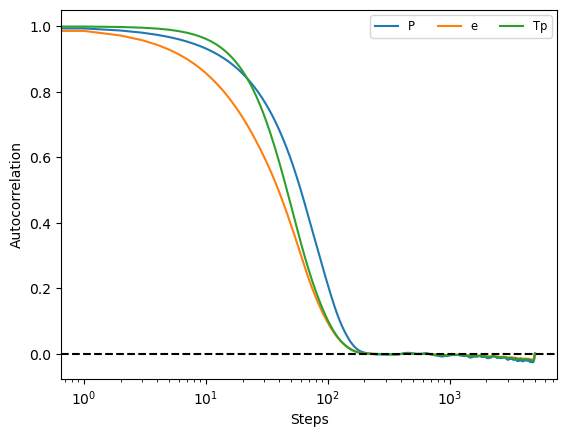

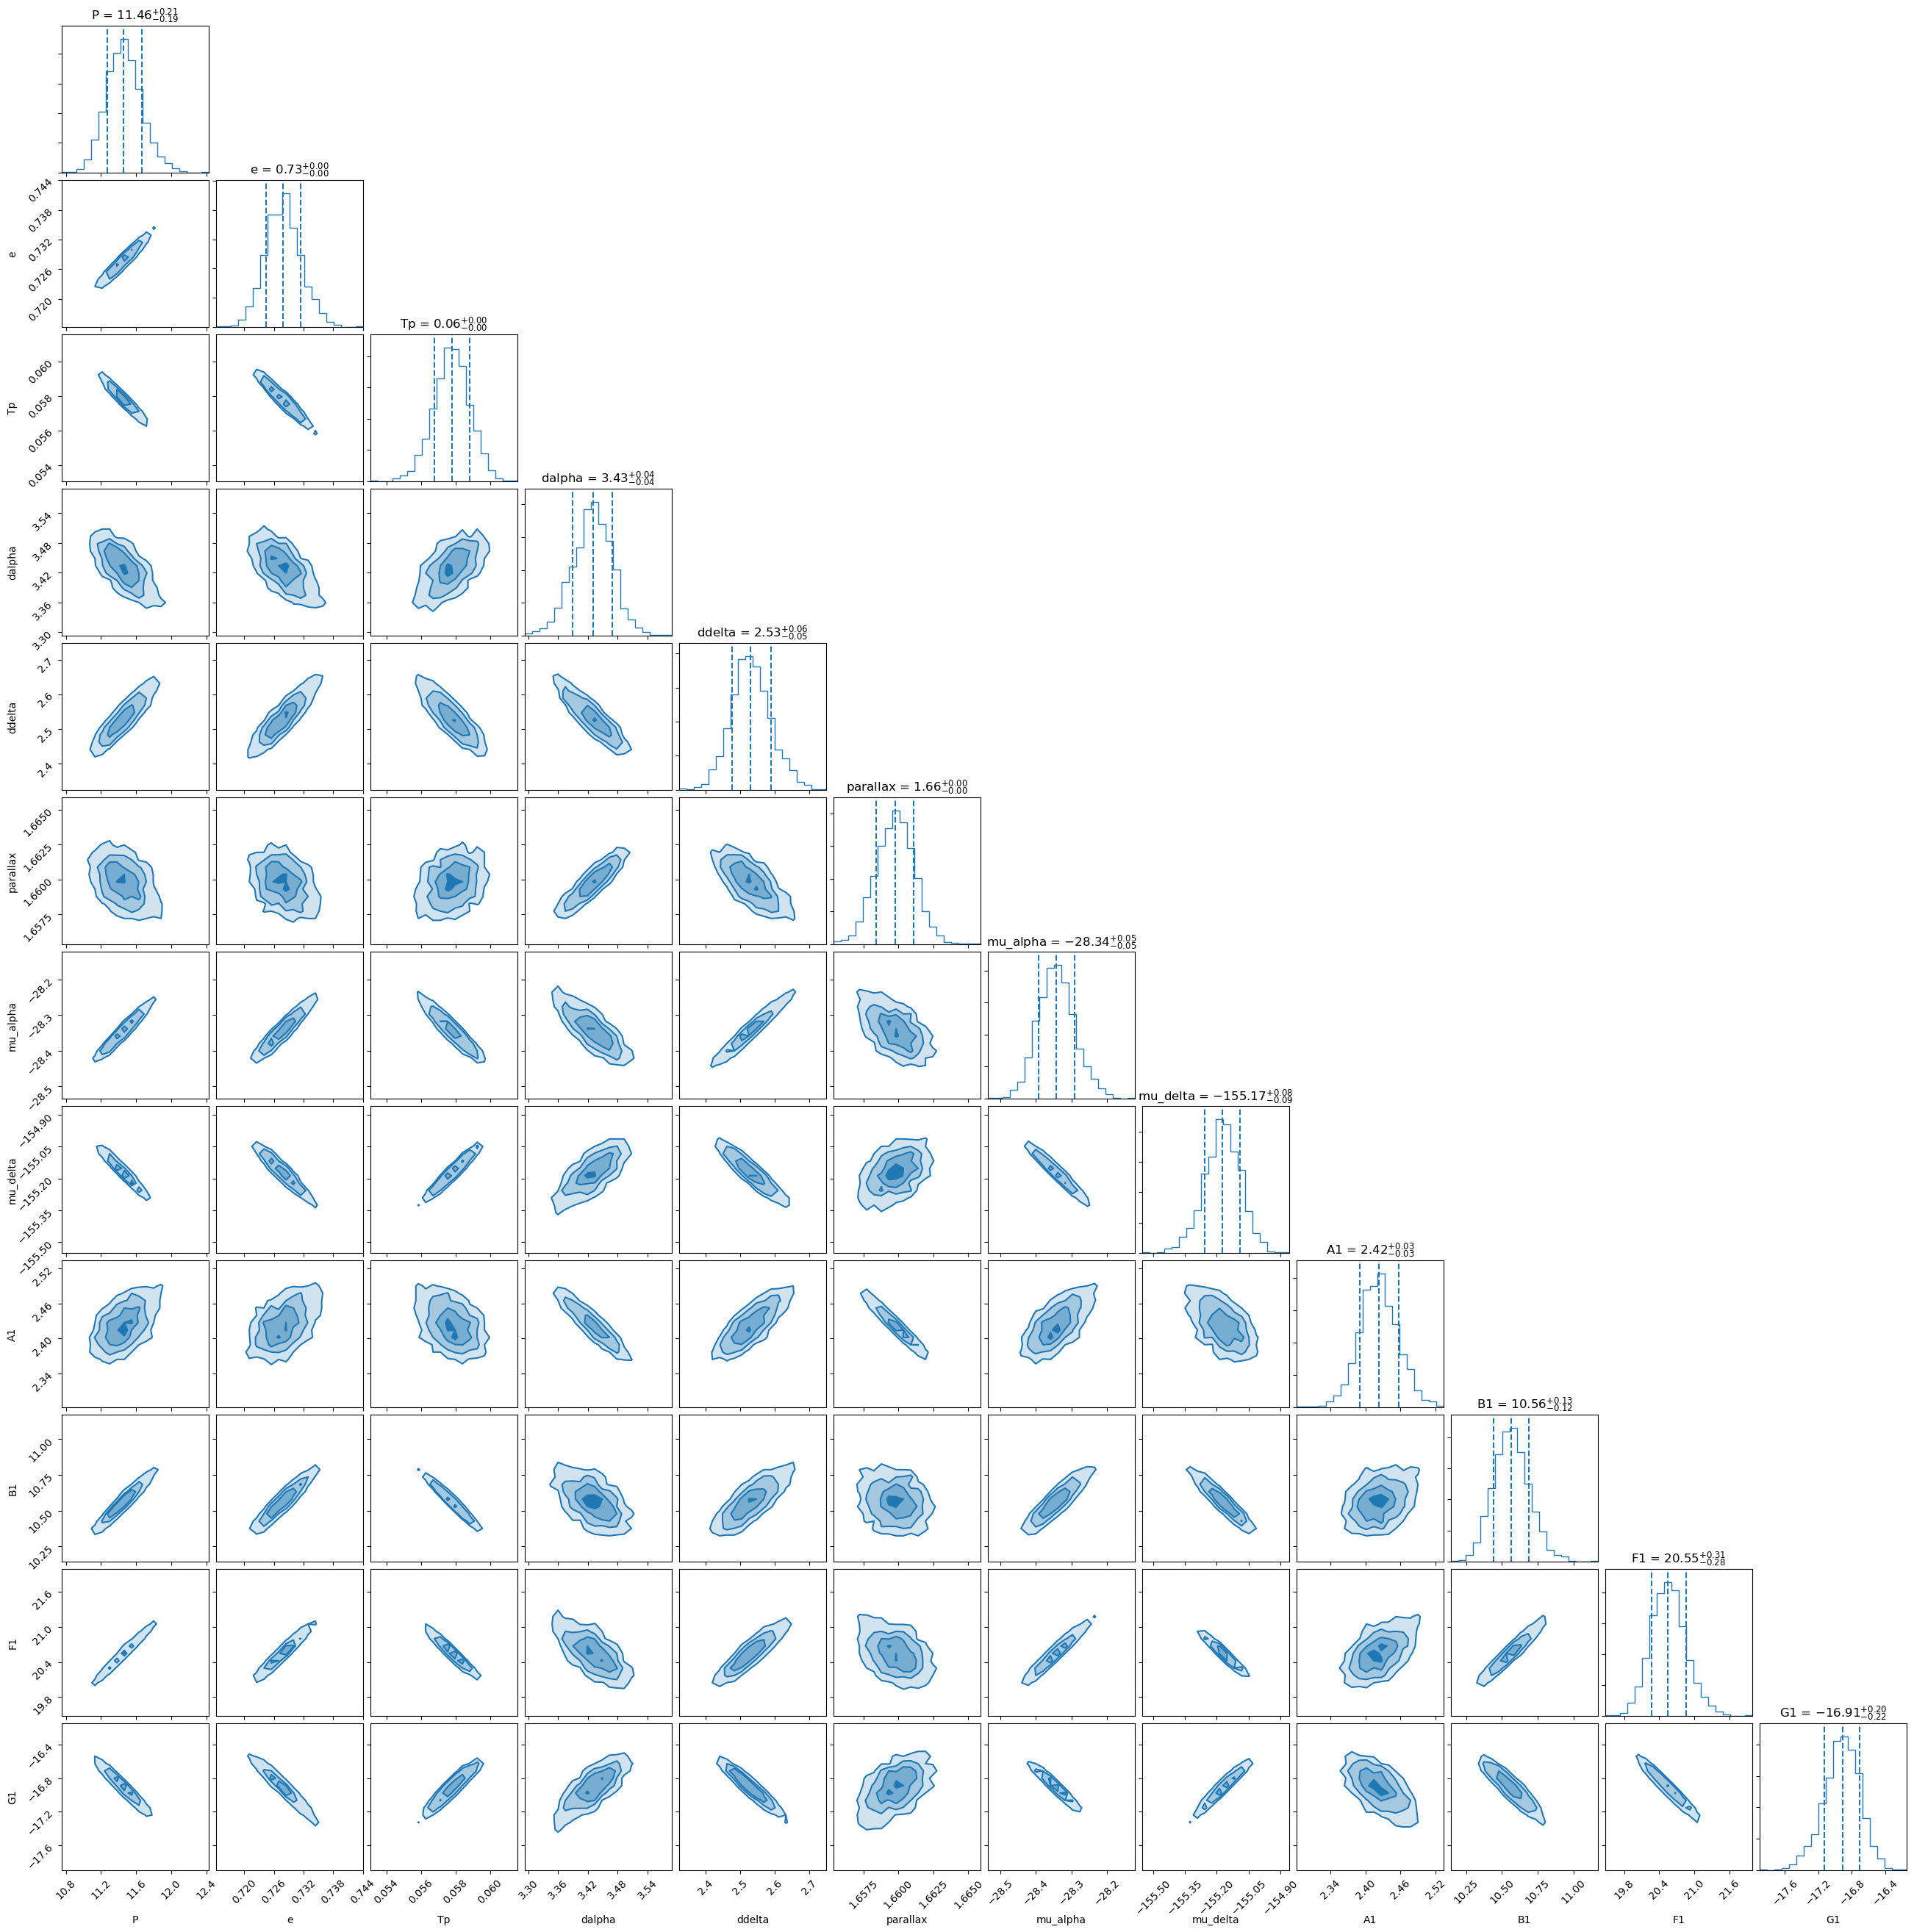

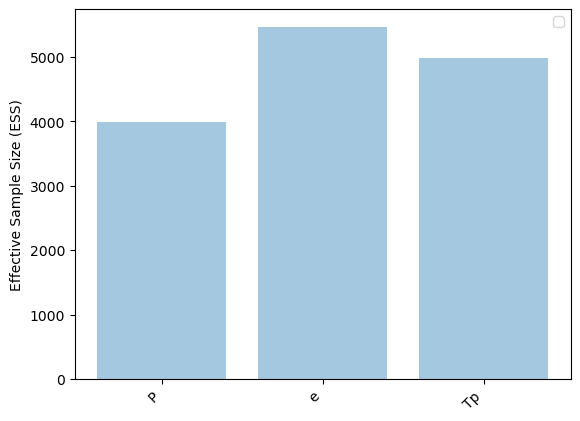

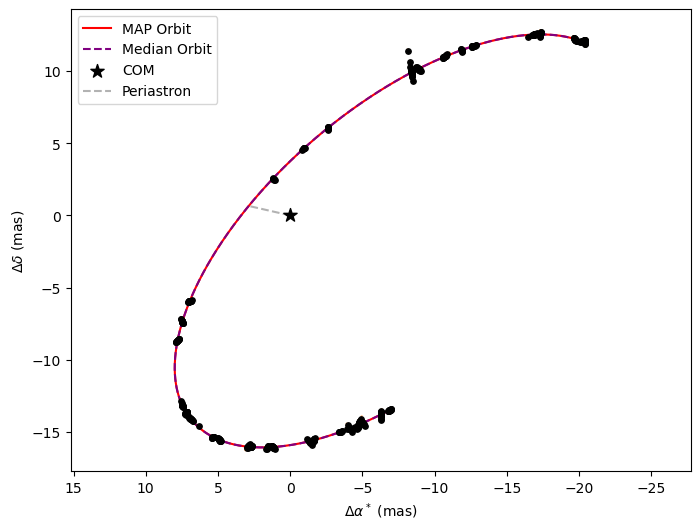

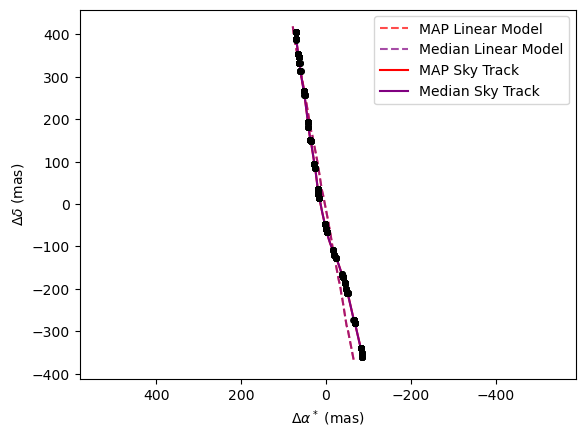

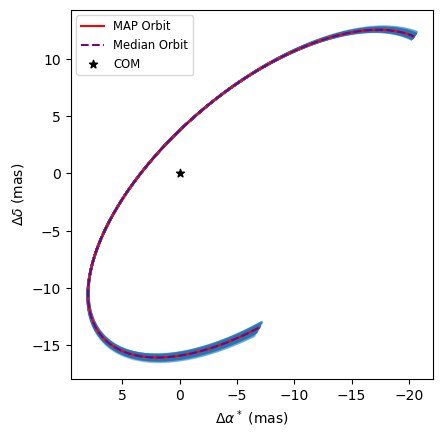

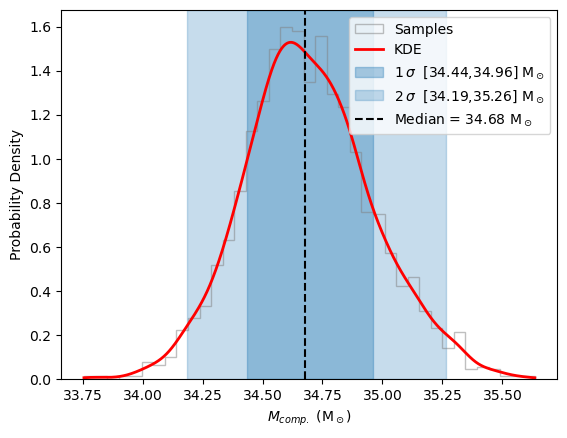

In [10]:
all_plots(results,data)

Now, sample with UltraNest instead

In [11]:
fitter2 = UltraNestGaia(nlive=400,min_ess=400, m1=m1_MS, **priors)
results2 = fitter2.fit(data)

In [12]:
stats2,fit_results2 = st.all_stats(results2,data)

{
    "credible_intervals": {
        "A1": {
            "+1sigma": 2.459390507429434,
            "+2sigma": 2.492486896263909,
            "-1sigma": 2.3895895259653113,
            "-2sigma": 2.35715649924909
        },
        "B1": {
            "+1sigma": 10.696409790116043,
            "+2sigma": 10.826974126454479,
            "-1sigma": 10.441823709089167,
            "-2sigma": 10.32155339751816
        },
        "F1": {
            "+1sigma": 20.870573081661483,
            "+2sigma": 21.178471556391855,
            "-1sigma": 20.27429655003565,
            "-2sigma": 19.971032947713645
        },
        "G1": {
            "+1sigma": -16.710634970129743,
            "+2sigma": -16.48714926976604,
            "-1sigma": -17.14202359280672,
            "-2sigma": -17.37577079512167
        },
        "M2": {
            "+1sigma": 34.97753322681276,
            "+2sigma": 35.2469730506343,
            "-1sigma": 34.425202719389446,
            "-2sigma": 34.16259110337244


(<Figure size 2650x2650 with 144 Axes>,
 <Figure size 800x600 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>)

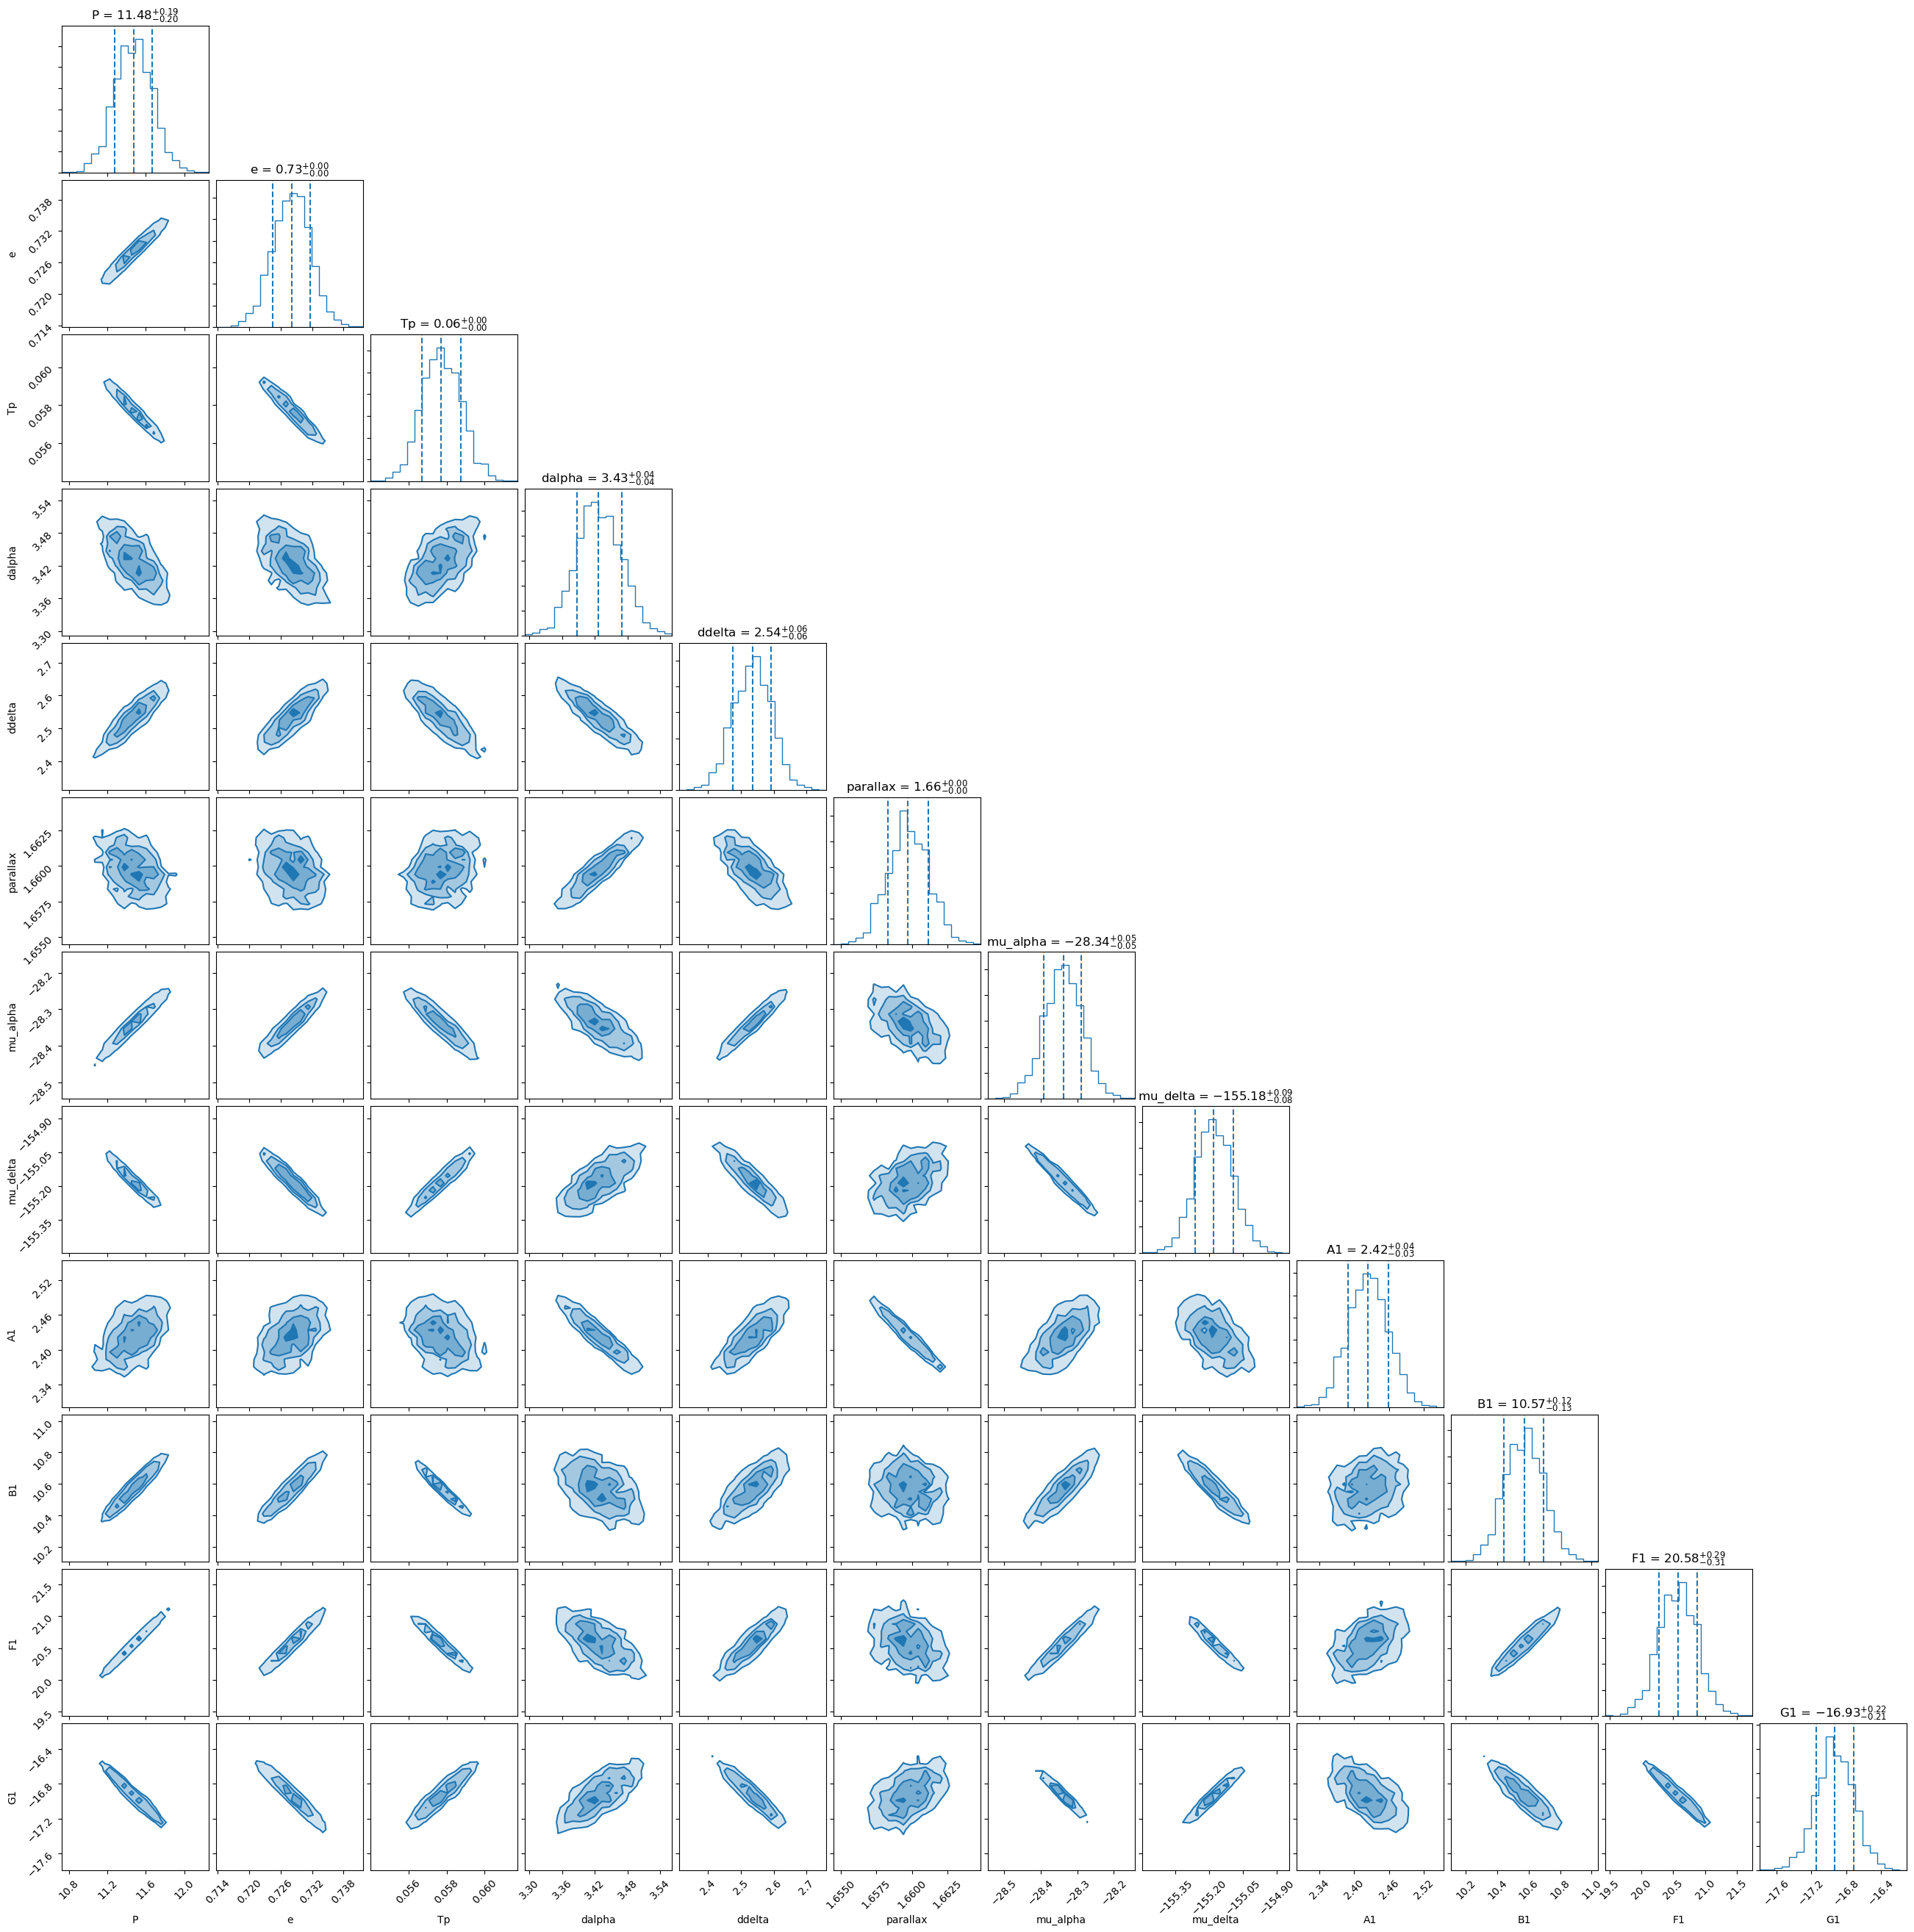

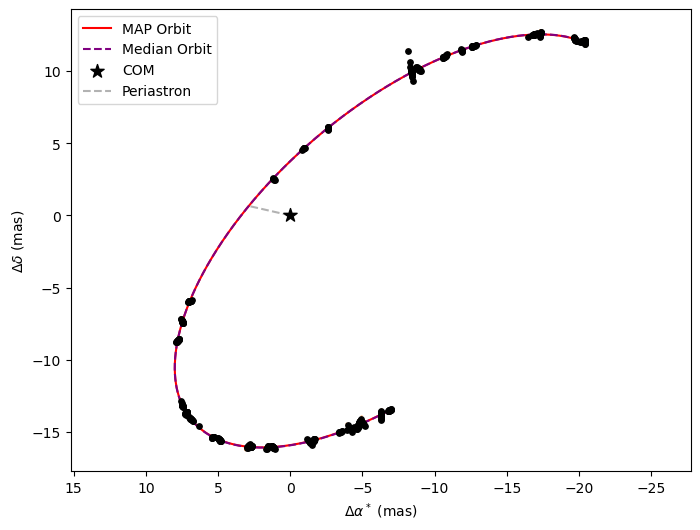

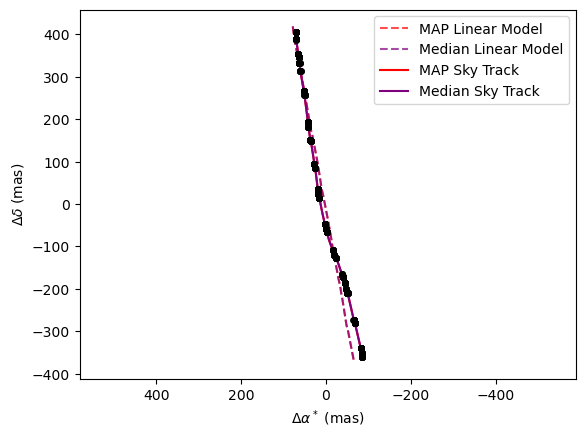

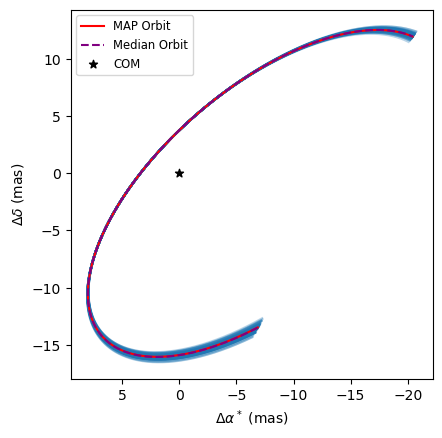

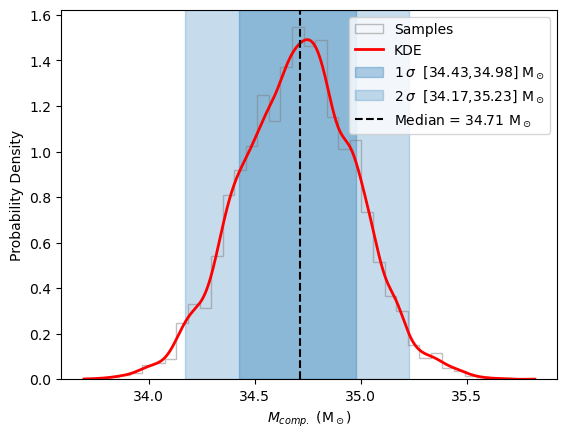

In [13]:
all_plots(results2,data)